In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv('/content/linearly_separable.csv')
df.sample(5)

,x1,x2,label
99,0.043157,0.311950,0.0
193,0.744076,0.910565,1.0
143,0.748063,0.773541,1.0
165,0.896307,0.754441,1.0
79,0.046348,0.055008,0.0


In [3]:
X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression using library

In [4]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [5]:
r2_score(y_test, y_pred)

1.0

In [25]:
model.coef_

array([[3.99921141, 3.92997709]])

In [26]:
model.intercept_

array([-3.94043083])

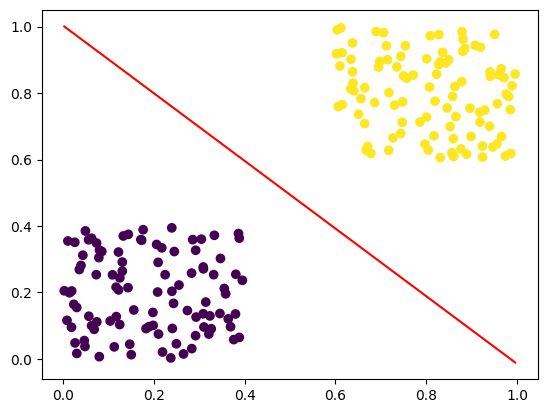

In [6]:
w = model.coef_[0]
b = model.intercept_[0]
X = X.to_numpy()

plt.scatter(X[:,0], X[:,1], c=y)

x_vals = np.linspace(min(X[:,0]), max(X[:,0]), 100)
y_vals = -(w[0]*x_vals + b) / w[1]

plt.plot(x_vals, y_vals, 'r')
plt.show()

# Implementation of Logistic Regression using perceptron trick

In [7]:
def Perceptron(X_train , y_train):
  X_train = np.insert(X_train , 0 , 1 , axis=1)
  weights = np.ones(X_train.shape[1])
  lr = 0.1

  for i in range(1000):
    index = np.random.randint(0 , X_train.shape[0])
    y_hat = step(np.dot(X_train[index] , weights))
    weights = weights + lr * (y_train[index] - y_hat) * X_train[index]

  return weights[1:] , weights[0]

In [8]:
def step(z):
    return 1 if z >= 0 else 0

In [9]:
coef_, intercept_ = Perceptron(X, y)

In [10]:
m = -coef_[0] / coef_[1]
c = -intercept_ / coef_[1]

x_vals = np.linspace(min(X[:,0]), max(X[:,0]), 100)
y_vals = m * x_vals + c

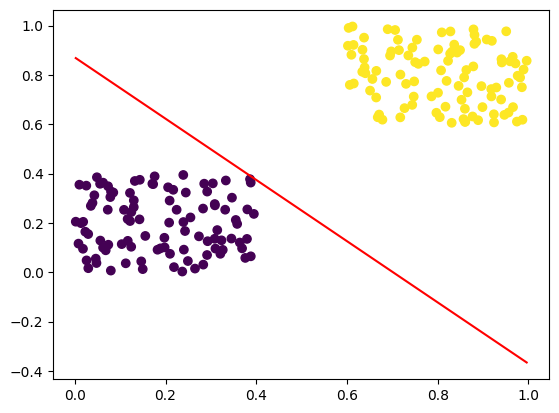

In [11]:
plt.plot(x_vals, y_vals, 'r')
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

# Logistic Regression using Sigmoid Function

In [17]:
def Sigmoid_Logistic_Regression(X_train , y_train):
  X_train = np.insert(X_train , 0 , 1 , axis=1)
  weights = np.ones(X_train.shape[1])
  lr = 0.1

  for i in range(1000):
    index = np.random.randint(0 , X_train.shape[0])
    y_hat = step(np.dot(X_train[index] , weights))
    weights = weights + lr * (y_train[index] - y_hat) * X_train[index]

  return weights[1:] , weights[0]

In [18]:
def step(z):
    return 1 / (1 + np.exp(-z))

In [19]:
coef_, intercept_ = Sigmoid_Logistic_Regression(X, y)

In [20]:
m = -coef_[0] / coef_[1]
c = -intercept_ / coef_[1]

x_vals = np.linspace(min(X[:,0]), max(X[:,0]), 100)
y_vals = m * x_vals + c

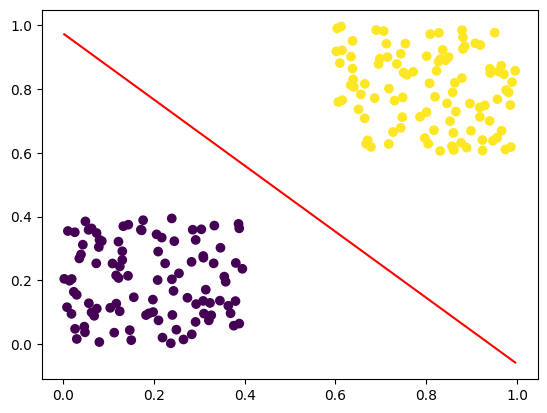

In [21]:
plt.plot(x_vals, y_vals, 'r')
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

# Logistic Regression Implemented Using loss function

In [275]:
def LogisticRegression(X_train , y_train):
  X = X_train.values
  y = y_train.values
  X = np.insert(X , 0 , 1 , axis=1)
  weights = np.ones(X.shape[1])
  lr = 0.1

  # Stochastic Gradient Descent
  # for i in range(1000):
  #   idx = np.random.randint(0 , X.shape[0])
  #   y_hat = sigmoid(np.dot(X[idx] , weights))
  #   loss_func_der = ((y[idx] - y_hat) * X[idx])

  #   weights = weights + lr * loss_func_der

  # Batch Gradient Descent
  for i in range(1200):
    y_hat = sigmoid(np.dot(X , weights))
    loss_func_der = np.dot(X.T , (y - y_hat)) / X.shape[0]

    weights = weights + lr * loss_func_der

  return weights[1:] , weights[0]

In [276]:
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

In [277]:
coef_ , intercept_ = LogisticRegression(X_train , y_train)

In [278]:
coef_

array([4.34128004, 4.19266984])

In [279]:
intercept_

np.float64(-4.046964865222715)

In [280]:
m = -coef_[0] / coef_[1]
c = -intercept_ / coef_[1]

x_vals = np.linspace(min(X[:,0]), max(X[:,0]), 100)
y_vals = m * x_vals + c

In [281]:
m

np.float64(-1.0354452413884914)

In [282]:
c

np.float64(0.9652476858110993)

In [283]:
x_vals

array([0.00220885, 0.01224736, 0.02228587, 0.03232438, 0.0423629 ,
       0.05240141, 0.06243992, 0.07247843, 0.08251694, 0.09255546,
       0.10259397, 0.11263248, 0.12267099, 0.1327095 , 0.14274802,
       0.15278653, 0.16282504, 0.17286355, 0.18290206, 0.19294058,
       0.20297909, 0.2130176 , 0.22305611, 0.23309462, 0.24313314,
       0.25317165, 0.26321016, 0.27324867, 0.28328718, 0.2933257 ,
       0.30336421, 0.31340272, 0.32344123, 0.33347974, 0.34351826,
       0.35355677, 0.36359528, 0.37363379, 0.3836723 , 0.39371082,
       0.40374933, 0.41378784, 0.42382635, 0.43386487, 0.44390338,
       0.45394189, 0.4639804 , 0.47401891, 0.48405743, 0.49409594,
       0.50413445, 0.51417296, 0.52421147, 0.53424999, 0.5442885 ,
       0.55432701, 0.56436552, 0.57440403, 0.58444255, 0.59448106,
       0.60451957, 0.61455808, 0.62459659, 0.63463511, 0.64467362,
       0.65471213, 0.66475064, 0.67478915, 0.68482767, 0.69486618,
       0.70490469, 0.7149432 , 0.72498171, 0.73502023, 0.74505

In [284]:
y_vals

array([ 0.96296055,  0.95256622,  0.94217189,  0.93177756,  0.92138323,
        0.9109889 ,  0.90059457,  0.89020024,  0.87980591,  0.86941158,
        0.85901725,  0.84862292,  0.83822859,  0.82783426,  0.81743993,
        0.8070456 ,  0.79665127,  0.78625694,  0.77586261,  0.76546828,
        0.75507396,  0.74467963,  0.7342853 ,  0.72389097,  0.71349664,
        0.70310231,  0.69270798,  0.68231365,  0.67191932,  0.66152499,
        0.65113066,  0.64073633,  0.630342  ,  0.61994767,  0.60955334,
        0.59915901,  0.58876468,  0.57837035,  0.56797602,  0.55758169,
        0.54718736,  0.53679303,  0.52639871,  0.51600438,  0.50561005,
        0.49521572,  0.48482139,  0.47442706,  0.46403273,  0.4536384 ,
        0.44324407,  0.43284974,  0.42245541,  0.41206108,  0.40166675,
        0.39127242,  0.38087809,  0.37048376,  0.36008943,  0.3496951 ,
        0.33930077,  0.32890644,  0.31851211,  0.30811779,  0.29772346,
        0.28732913,  0.2769348 ,  0.26654047,  0.25614614,  0.24

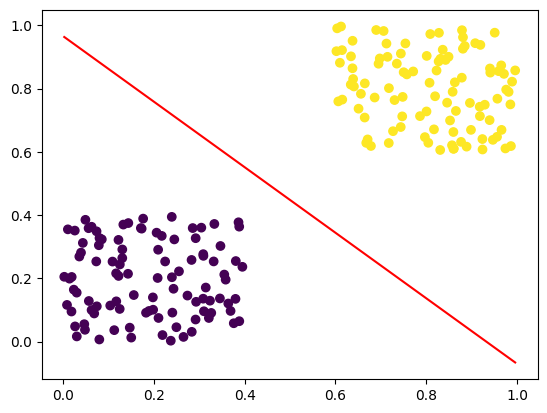

In [285]:
plt.plot(x_vals, y_vals, 'r')
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()